In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from orbfit.fitting import LBFGSBFitter
from orbfit.gp_tools import sample_gp
from orbfit.loading import load_default
from orbfit.mcmc import MCMCSampler
from orbfit.models import REBOUNDModel, GPNoise, predict_resid
from orbfit.plotting import plot_data, plot_trace, plot_corner, plot_resid, plot_acor
from orbfit.priors import UniformPrior

In [4]:
data = load_default()

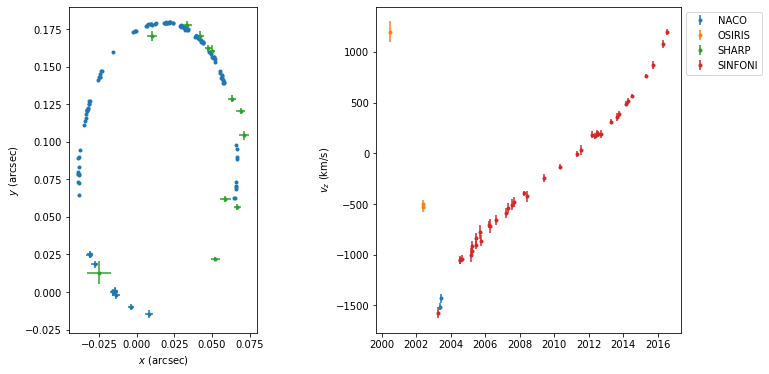

In [5]:
plot_data(data, figsize=(12, 6))
plt.show()

In [6]:
class Model(REBOUNDModel, GPNoise):
    pass

model = Model()

names, priors = map(list, zip(*[
    ("M0", UniformPrior(3, 5)),
    ("R0", UniformPrior(7, 9)),
    ("a", UniformPrior(0.10, 0.15)),
    ("e", UniformPrior(0.87, 0.90)),
    ("inc", UniformPrior(2.3, 2.5)),
    ("Omega", UniformPrior(3.9, 4.1)),
    ("omega", UniformPrior(1.0, 1.2)),
    ("tp", UniformPrior(2002.1, 2002.5)),
    ("x0", UniformPrior(-5e-3, 5e-3)),
    ("y0", UniformPrior(-5e-3, 5e-3)),   
    ("vx0", UniformPrior(-1e-3, 1e-3)),
    ("vy0", UniformPrior(-1e-3, 1e-3)),  
    ("vz0", UniformPrior(0, 50)),
    ("log_s2", UniformPrior(np.log(0.01e-6), np.log(1e-3))),
    ("log_taux", UniformPrior(np.log(0.01), np.log(5))),
    ("log_tauy", UniformPrior(np.log(0.01), np.log(5)))]))

In [7]:
sampler = MCMCSampler(data, names, priors, model, nwalkers=80, checkpoint="chain.h5")

In [8]:
#sampler.sample_orbit(10000, processes=32)

In [9]:
sampler.restore()

In [10]:
sampler.nburn = 2000

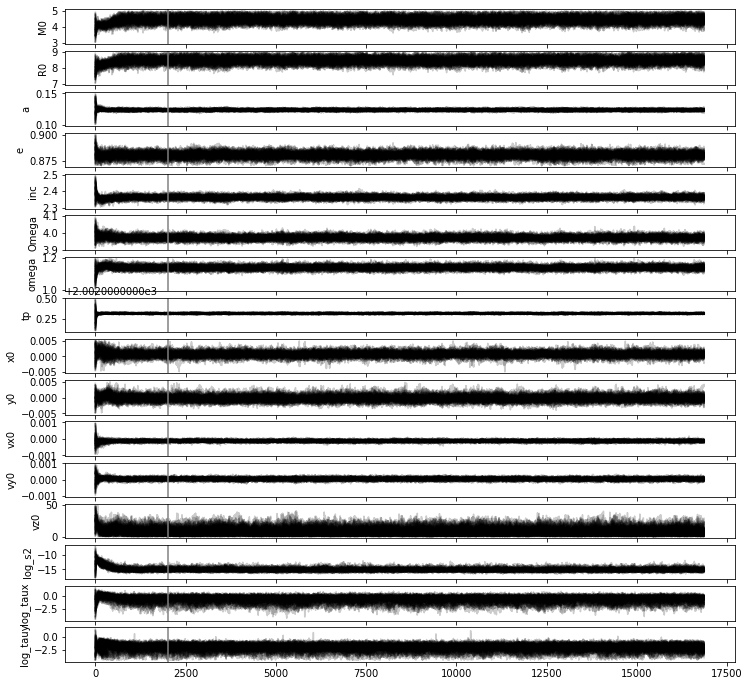

In [11]:
plot_trace(sampler, figsize=(12, 12))
plt.show()

In [12]:
#plot_trace(sampler, show_burnin=False, figsize=(12, 12))
#plt.show()

In [13]:
sampler.get_autocorr_time(quiet=True)

253.28831919575697

Compute autocorrelation times:   0%|          | 0/10 [00:00<?, ?it/s]

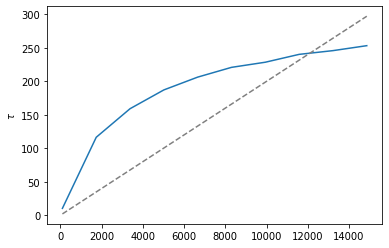

In [14]:
plot_acor(sampler)
plt.show()

In [15]:
theta_init = sampler.get_mean(as_array=True)
bounds = [prior.bounds() for prior in priors]

In [16]:
fitter = LBFGSBFitter(data, names, bounds, model)

In [17]:
fitter.fit_orbit(theta_init)

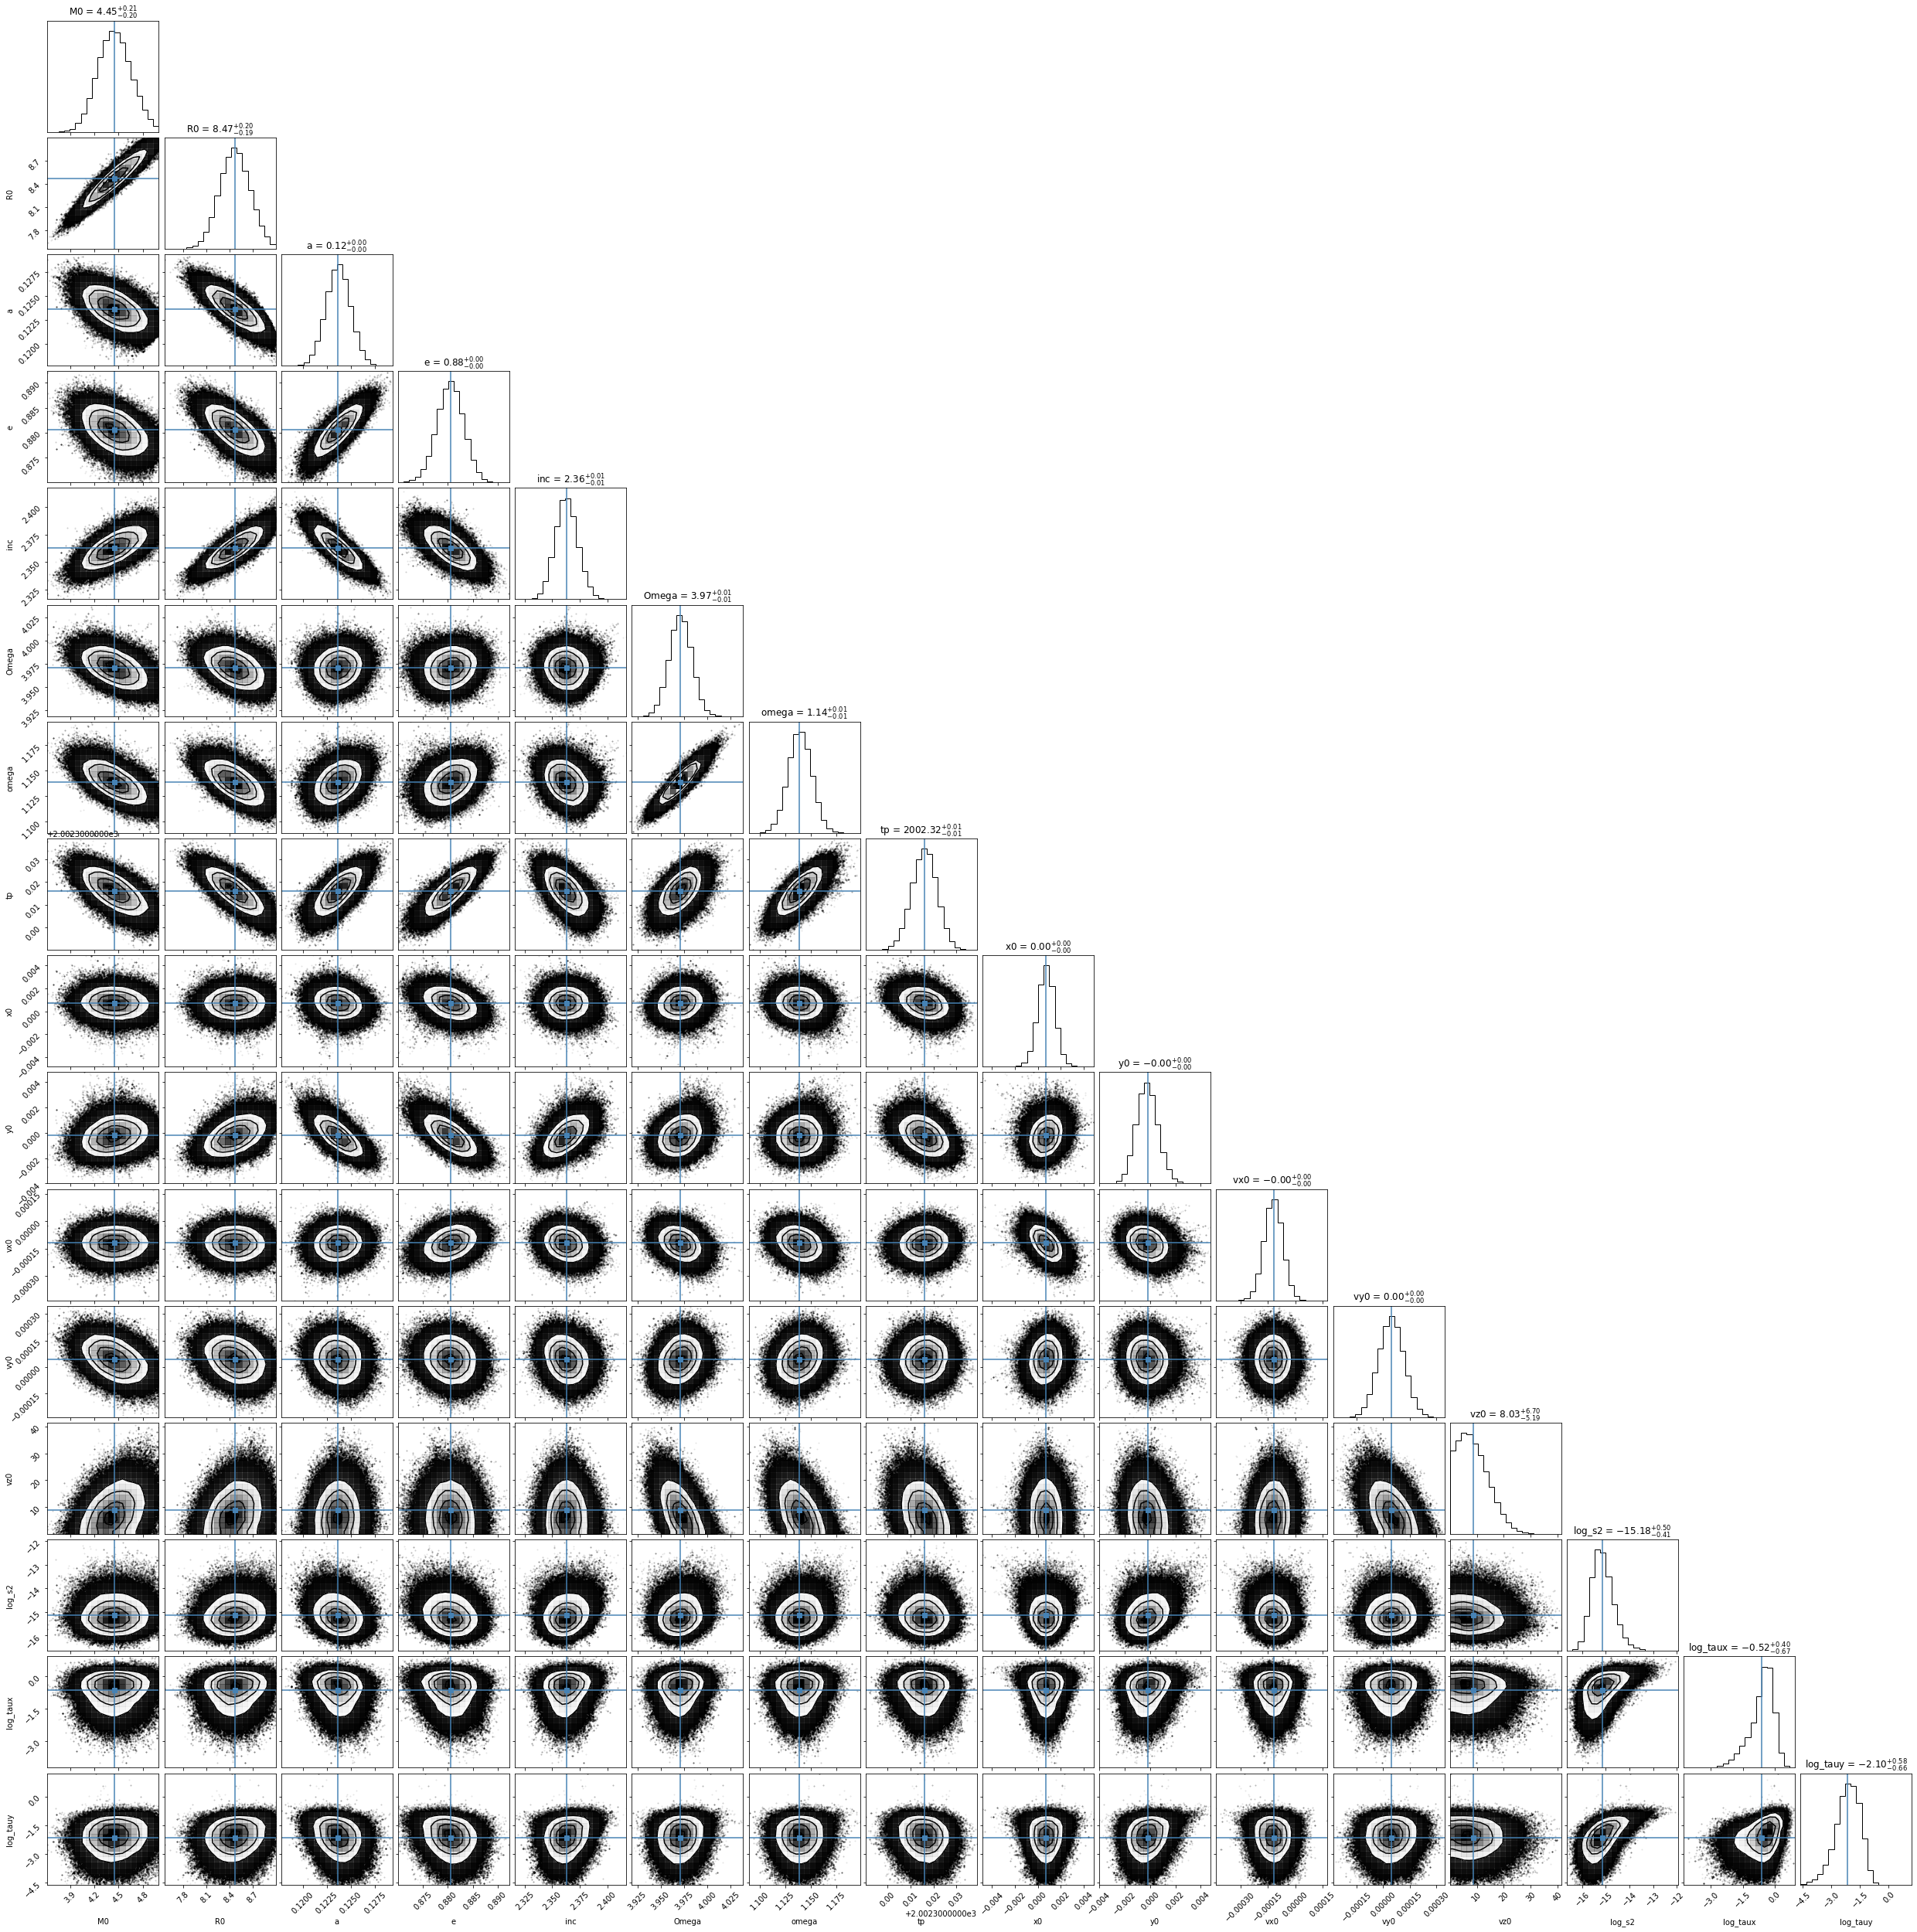

In [18]:
plot_corner(sampler, theta=fitter.get_best_fit(as_array=True))
plt.show()

In [19]:
best_orbit = fitter.get_best_fit()

In [20]:
best_orbit

{'M0': 4.447227265812414,
 'R0': 8.472206640131319,
 'a': 0.12361578359506983,
 'e': 0.8805485214184662,
 'inc': 2.3627609658460007,
 'Omega': 3.9711966515520554,
 'omega': 1.1387810792637627,
 'tp': 2002.316115316032,
 'x0': 0.0007199222147379284,
 'y0': -0.00018553528553220155,
 'vx0': -0.0001163380885811321,
 'vy0': 4.393037495991704e-05,
 'vz0': 8.81193315946326,
 'log_s2': -15.140560430443943,
 'log_taux': -0.6280352459198871,
 'log_tauy': -2.1517651395564266}

In [21]:
1e3*np.sqrt(np.exp(best_orbit["log_s2"]))

0.5155479639827989

In [22]:
np.exp(best_orbit["log_taux"])

0.5336392415655665

In [23]:
np.exp(best_orbit["log_tauy"])

0.11627872833806353

In [24]:
fit_resid = predict_resid(best_orbit, data, model)

Compute GP samples:   0%|          | 0/100 [00:00<?, ?it/s]

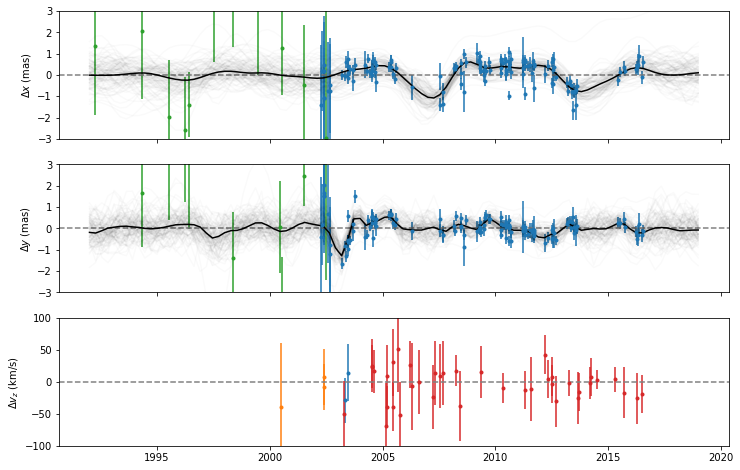

In [25]:
fig, ax = plot_resid(fit_resid, figsize=(12, 8))

t_val = np.linspace(1992, 2019, 100)

gp_mean = sample_gp(best_orbit, data, model, t_val, n=100)

gp_samples = pd.DataFrame(index=t_val)
for i in tqdm(range(100), desc="Compute GP samples"):
    df = sample_gp(sampler.get_sample(), data, model, gp_samples.index)
    gp_samples[[f"x-{i}", f"y-{i}"]] = df[["x", "y"]]

gp_mean *= 1e3
gp_samples *= 1e3

gp_samples.filter(regex="x-").plot(ax=ax[0], color="k", alpha=0.02, legend=None)
gp_samples.filter(regex="y-").plot(ax=ax[1], color="k", alpha=0.02, legend=None)
gp_mean.plot(ax=ax[0], y="x", color="k", legend=None)
gp_mean.plot(ax=ax[1], y="y", color="k", legend=None)

ax[0].set_ylim([-3, 3])
ax[1].set_ylim([-3, 3])
ax[2].set_ylim([-100, 100])

ax[0].legend_.remove()

plt.show()